# PDBbind density normalisation: distribution comparison

Three density-normalisation variants of the PDBbind pocket crops, all on the same 4,827 complexes:

| Version | Pipeline | Output range |
|---|---|---|
| **v1** | per-map global z-score (`_load_grid`) → trilinear crop at ligand COM → per-crop ±3σ clip + re-z-score (`normalize_crop`) | ≈ mean 0, std 1, hard-clipped at ±3 |
| **v2** | raw CCP4 → trilinear crop → pocket-pool z-score `(x − μ_pool) / σ_pool` | mean 0, std 1 across the pool |
| **v3** | raw CCP4 → trilinear crop → pocket-pool symmetric max-abs `x / max_abs_pool` | strict `[−1, +1]` |

Three views in this notebook:
1. Pool-wide value histograms (concatenated over a sample of crops)
2. Distributions of per-crop summary stats (mean, std, max, min)
3. Same-PDB-ID side-by-side density slices + value distributions

In [1]:
import os, sys, json, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PDBBIND_DIR = Path("..") / "voxbind" / "dataset" / "data" / "pdbbind"
VOX_DIRS = {
    "v1": PDBBIND_DIR / "voxels",
    "v2": PDBBIND_DIR / "voxels_v2",
    "v3": PDBBIND_DIR / "voxels_v3",
}
COLOR = {"v1": "#3498db", "v2": "#e67e22", "v3": "#2ecc71"}
LABEL = {
    "v1": "v1: per-map z + per-crop ±3σ",
    "v2": "v2: pocket-pool z-score",
    "v3": "v3: pocket-pool max-abs",
}

for v, d in VOX_DIRS.items():
    n = len(list((d / "density").glob("*.npy"))) if (d / "density").exists() else 0
    print(f"  {v}  {n:>5} density files  at  {d / 'density'}")

  v1   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels/density
  v2   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v2/density
  v3   4827 density files  at  ../voxbind/dataset/data/pdbbind/voxels_v3/density


## 1. Pool-wide value distribution

Sample N random crops per version, concatenate all voxels, plot the value distribution. Same N pids across versions so the comparison is fair.

In [ ]:
N_SAMPLE = 200            # 200 × 64³ = ~52 M voxels per version → enough for a clean histogram
rng = random.Random(0)

# Common pid pool: pids present in ALL three versions
pids_per_ver = {v: {p.stem for p in (d / "density").glob("*.npy")} for v, d in VOX_DIRS.items()}
shared = sorted(set.intersection(*pids_per_ver.values()))
print(f"shared pids across v1/v2/v3 : {len(shared):,}")
sample_pids = rng.sample(shared, k=min(N_SAMPLE, len(shared)))

pooled = {}
for v, d in VOX_DIRS.items():
    arrs = [np.load(d / "density" / f"{pid}.npy").astype(np.float32).ravel() for pid in sample_pids]
    pooled[v] = np.concatenate(arrs)
    print(f"  {v:3s} pool: {pooled[v].size:>10,d} voxels   "
          f"range [{pooled[v].min():+.3f}, {pooled[v].max():+.3f}]   "
          f"mean {pooled[v].mean():+.4f}   std {pooled[v].std():.4f}")

shared pids across v1/v2/v3 : 4,827
  v1  pool: 52,428,800 voxels   range [-3.000, +3.000]   mean -0.0080   std 0.9659
  v2  pool: 52,428,800 voxels   range [-5.117, +60.656]   mean +0.0022   std 0.9908
  v3  pool: 52,428,800 voxels   range [-0.056, +0.660]   mean +0.0001   std 0.0108


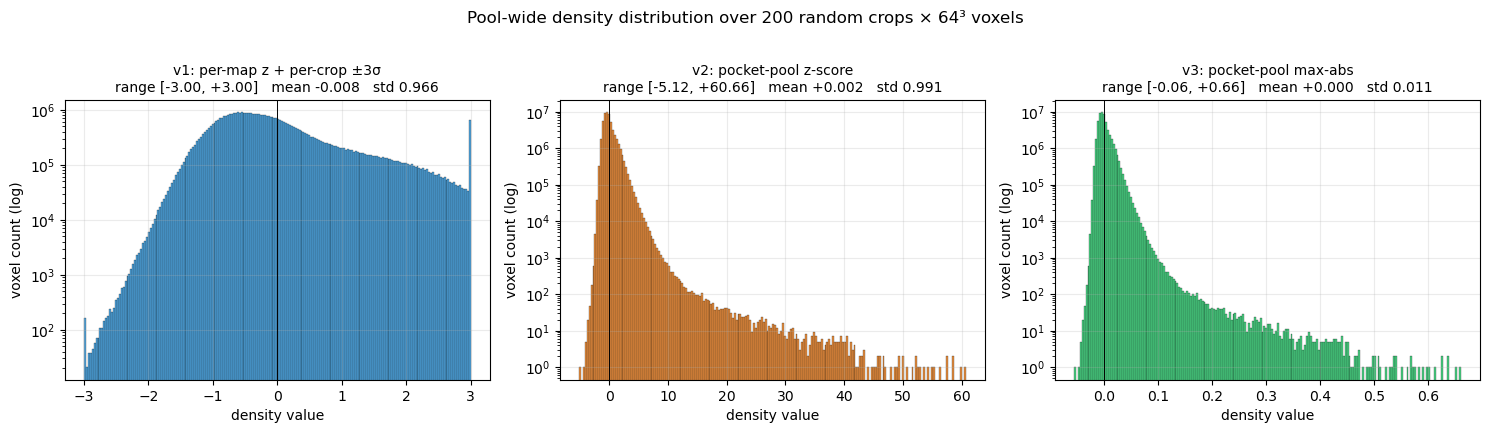

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, v in zip(axes, ["v1", "v2", "v3"]):
    vals = pooled[v]
    ax.hist(vals, bins=200, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
    ax.set_yscale("log")
    ax.axvline(0, color="k", linewidth=0.7)
    ax.set_title(
        f"{LABEL[v]}\nrange [{vals.min():+.2f}, {vals.max():+.2f}]   "
        f"mean {vals.mean():+.3f}   std {vals.std():.3f}",
        fontsize=10,
    )
    ax.set_xlabel("density value")
    ax.set_ylabel("voxel count (log)")
    ax.grid(alpha=0.25)
fig.suptitle(f"Pool-wide density distribution over {N_SAMPLE} random crops × 64³ voxels", y=1.02)
fig.tight_layout()
plt.show()

## 2. Per-crop statistic distributions

For each crop in the sample, compute its own mean / std / min / max. Plot the distribution of those per-crop stats across versions.

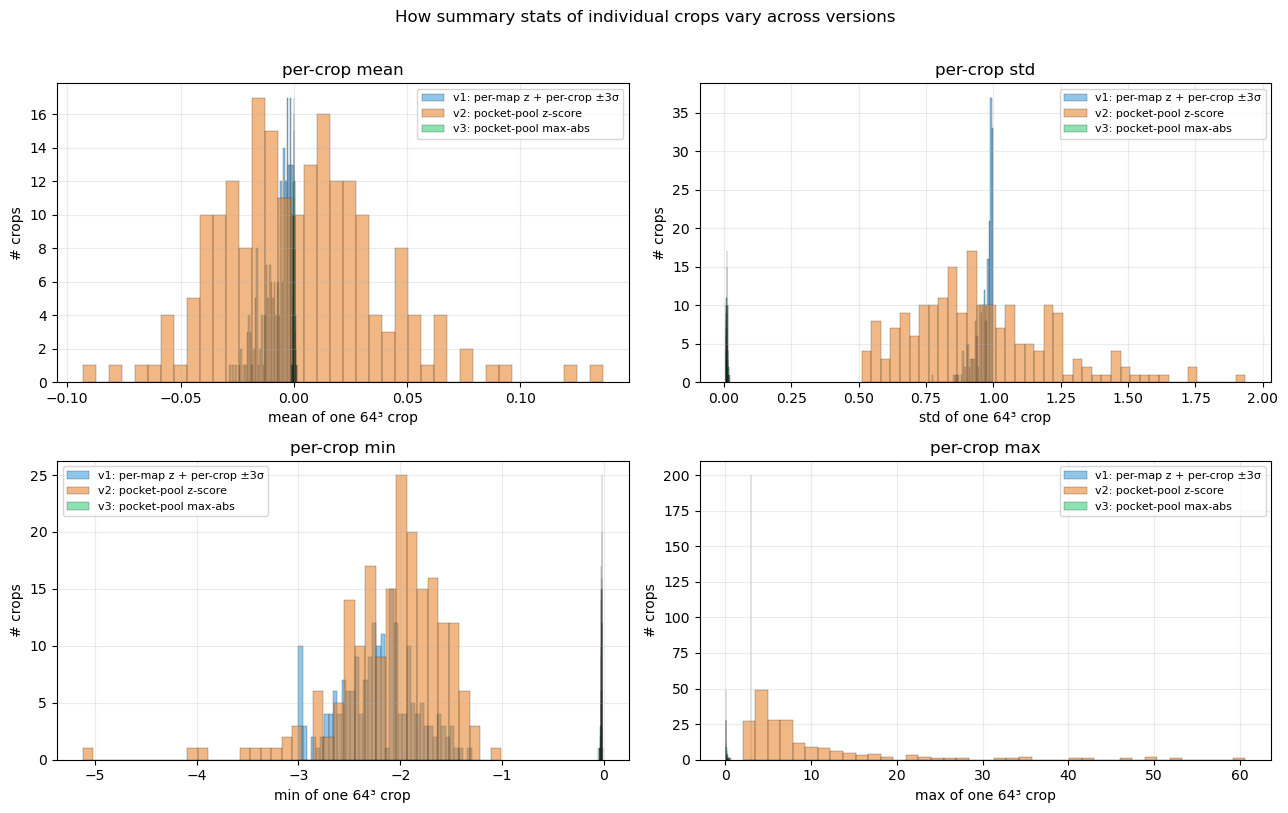

In [4]:
per_crop_stats = {v: {"mean": [], "std": [], "min": [], "max": []} for v in VOX_DIRS}
for v, d in VOX_DIRS.items():
    for pid in sample_pids:
        a = np.load(d / "density" / f"{pid}.npy").astype(np.float32)
        per_crop_stats[v]["mean"].append(a.mean())
        per_crop_stats[v]["std"].append(a.std())
        per_crop_stats[v]["min"].append(a.min())
        per_crop_stats[v]["max"].append(a.max())

for v in VOX_DIRS:
    for k in per_crop_stats[v]:
        per_crop_stats[v][k] = np.array(per_crop_stats[v][k])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, key in zip(axes.flat, ["mean", "std", "min", "max"]):
    for v in ["v1", "v2", "v3"]:
        ax.hist(per_crop_stats[v][key], bins=40, alpha=0.55,
                color=COLOR[v], label=LABEL[v], edgecolor="black", linewidth=0.3)
    ax.set_title(f"per-crop {key}")
    ax.set_xlabel(f"{key} of one 64³ crop")
    ax.set_ylabel("# crops")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle("How summary stats of individual crops vary across versions", y=1.01)
fig.tight_layout()
plt.show()

## 3. Same-PDB-ID side-by-side

Pick one complex (`PID` below); show the central slice along each of the three axes for v1, v2, v3 — so the same physical pocket is visualised under all three normalisations. The middle-row strip plots the value histogram per version for this single crop.

In [5]:
PID = "10gs"          # change to inspect a different complex (must exist in all three versions)

crops = {v: np.load(VOX_DIRS[v] / "density" / f"{PID}.npy").astype(np.float32) for v in VOX_DIRS}
for v, a in crops.items():
    print(f"  {v}  shape={a.shape}  range [{a.min():+.3f}, {a.max():+.3f}]  "
          f"mean {a.mean():+.4f}  std {a.std():.4f}")

  v1  shape=(64, 64, 64)  range [-2.535, +3.000]  mean -0.0061  std 0.9788
  v2  shape=(64, 64, 64)  range [-2.037, +4.551]  mean -0.0519  std 0.7832
  v3  shape=(64, 64, 64)  range [-0.022, +0.050]  mean -0.0005  std 0.0085


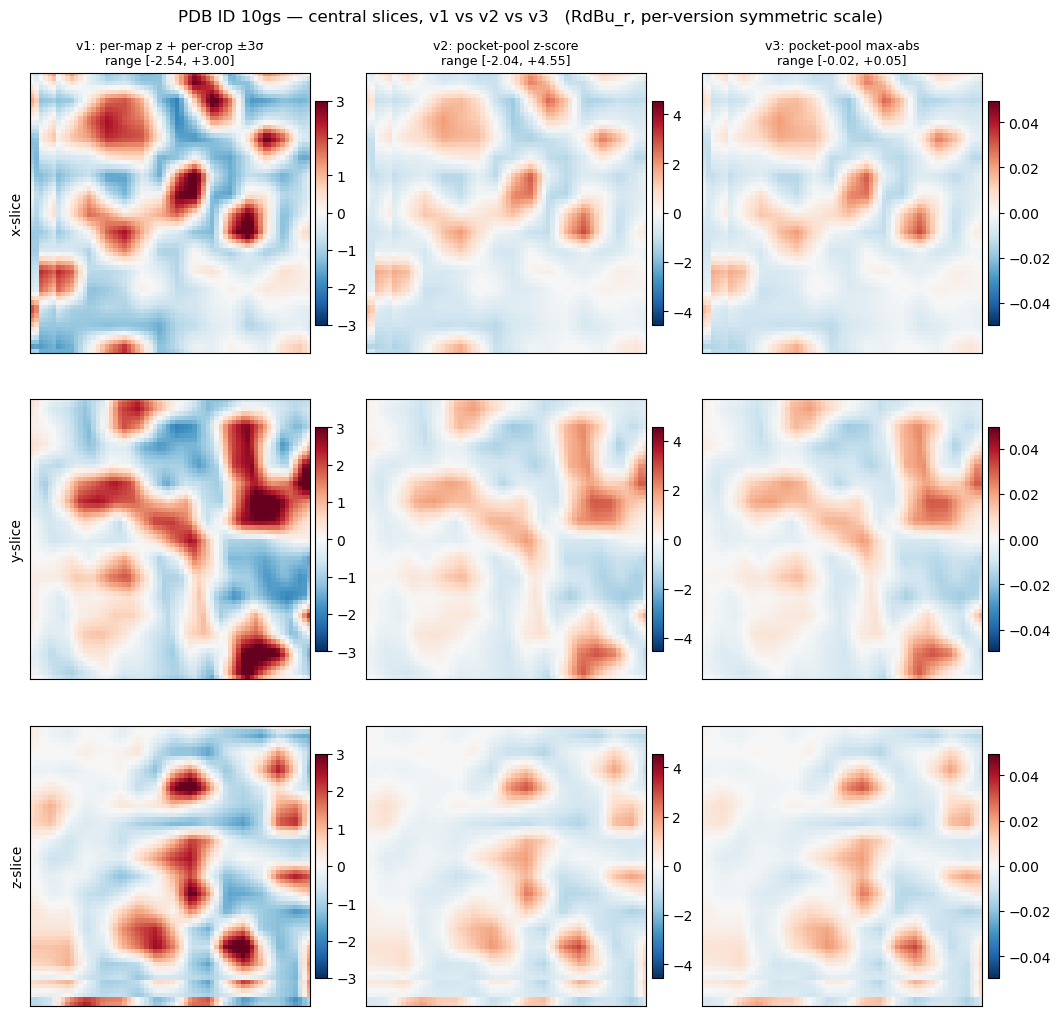

In [6]:
def take_slice(vol, axis, offset=0):
    G = vol.shape[-1]
    idx = G // 2 + offset
    return vol[idx, :, :] if axis == 'x' else vol[:, idx, :] if axis == 'y' else vol[:, :, idx]

fig, axes = plt.subplots(3, 3, figsize=(10.5, 10), constrained_layout=True)
for col, v in enumerate(["v1", "v2", "v3"]):
    a = crops[v]
    vmax = max(abs(a.min()), abs(a.max()))
    for row, axis in enumerate(['x', 'y', 'z']):
        ax = axes[row, col]
        im = ax.imshow(take_slice(a, axis).T, origin='lower',
                       cmap='RdBu_r', vmin=-vmax, vmax=+vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{LABEL[v]}\nrange [{a.min():+.2f}, {a.max():+.2f}]",
                         fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{axis}-slice", fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle(f"PDB ID {PID} — central slices, v1 vs v2 vs v3   "
             f"(RdBu_r, per-version symmetric scale)", y=1.02)
plt.show()

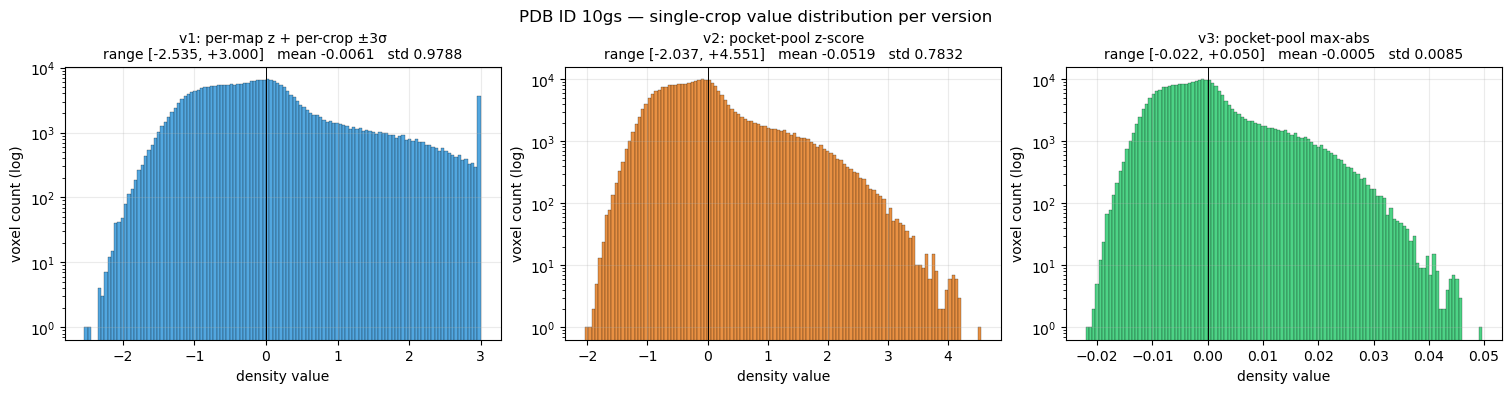

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), constrained_layout=True)
for ax, v in zip(axes, ["v1", "v2", "v3"]):
    vals = crops[v].ravel()
    ax.hist(vals, bins=120, color=COLOR[v], edgecolor="black", linewidth=0.2, alpha=0.85)
    ax.set_yscale("log")
    ax.axvline(0, color="k", linewidth=0.7)
    ax.set_title(
        f"{LABEL[v]}\n"
        f"range [{vals.min():+.3f}, {vals.max():+.3f}]   "
        f"mean {vals.mean():+.4f}   std {vals.std():.4f}",
        fontsize=10,
    )
    ax.set_xlabel("density value")
    ax.set_ylabel("voxel count (log)")
    ax.grid(alpha=0.25)
fig.suptitle(f"PDB ID {PID} — single-crop value distribution per version", y=1.05)
plt.show()

## 4. Pool stats from `stats.json`

The exact scalars used to construct v2 and v3 are recorded in each version's `stats.json`.

In [8]:
for v in ["v2", "v3"]:
    sj = VOX_DIRS[v] / "stats.json"
    if sj.exists():
        print(f"── {v} stats.json")
        print(json.dumps(json.loads(sj.read_text()), indent=2))
        print()

── v2 stats.json
{
  "scheme": "pocket-pool z-score",
  "formula": "x' = (x - mu) / sigma",
  "mu": 0.0021616171884043488,
  "sigma": 0.32965135634508996,
  "n_crops": 4827,
  "n_voxels_total": 1265369088,
  "raw_min": -2.3028321266174316,
  "raw_max": 30.303401947021484
}

── v3 stats.json
{
  "scheme": "pocket-pool symmetric max-abs",
  "formula": "x' = x / max_abs",
  "max_abs": 30.303401947021484,
  "n_crops": 4827,
  "n_voxels_total": 1265369088,
  "raw_min": -2.3028321266174316,
  "raw_max": 30.303401947021484
}



## Reading

Things to notice:

- **v1's histogram is hard-truncated at ±3** — the bins outside that range are empty (per-crop ±3σ clip + re-z-score). Heavy-atom peaks that were +8σ raw are pinned to +3 with no information about how much further they extended.
- **v2's histogram retains the long positive tail** — values out to +90 or so for the strongest metal peaks. Solvent / typical atom values cluster near 0 within a few σ_pool.
- **v3's histogram is in [−1, +1] strict** but most of the mass is squeezed into a tiny band near 0 because the single brightest peak (around +30 raw) sets the scale.
- The **per-crop std** plot (§2) reveals the trade-off directly: v1's per-crop std is ≈ 1 by construction; v2/v3's per-crop std varies *across* crops (some crops are denser than others — that signal survives in v2/v3 and is lost in v1).
- The **same-PID slices** (§3) show the same physical pocket under each transform — relative spatial pattern is preserved across all three; only the value scale differs.